In [2]:
from itertools import product
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


V2_2_ROOT = Path(
    "/shared/data_zfs/blue2959/ND_Aligner/experiments/v2.2"
)

EXPERIMENT_ROOTS = {
    "Conv1d": (
        V2_2_ROOT
        / "conv1d_rf_sweep"
        / "confirm"
    ),
    "TCD": (
        V2_2_ROOT
        / "TCD_rf_sweep"
        / "confirm"
    ),
}

OUTPUT_PDF = (
    V2_2_ROOT
    / "wbe_conv1d_tcd_2panel.pdf"
)

OUTPUT_PNG = (
    V2_2_ROOT
    / "wbe_conv1d_tcd_2panel.png"
)

# 문자열로 통일
SCORER_SETTINGS = ["l2", "1", "13"]
DECODER_RFS = [1, 5, 9, 13, 17]
SEEDS = [1234, 1235, 1236]

DIR_PATTERN = re.compile(
    r"^conv_RF=(?P<scorer_rf>l2|\d+)_"
    + r"dec_RF=(?P<decoder_rf>\d+)_"
    + r"seed=(?P<seed>\d+)$",
    flags=re.IGNORECASE,
)

In [3]:
def load_experiment_results(
    decoder_type: str,
    root_dir: Path,
) -> pd.DataFrame:
    if not root_dir.exists():
        raise FileNotFoundError(
            f"실험 디렉터리가 없습니다: {root_dir}"
        )

    records = []

    for experiment_dir in sorted(root_dir.iterdir()):
        if not experiment_dir.is_dir():
            continue

        match = DIR_PATTERN.fullmatch(
            experiment_dir.name
        )

        if match is None:
            continue

        scorer_rf = (
            match.group("scorer_rf").lower()
        )
        decoder_rf = int(
            match.group("decoder_rf")
        )
        seed = int(
            match.group("seed")
        )

        if scorer_rf not in SCORER_SETTINGS:
            continue

        if decoder_rf not in DECODER_RFS:
            continue

        if seed not in SEEDS:
            continue

        metric_path = (
            experiment_dir
            / "eval_metrics.csv"
        )

        if not metric_path.exists():
            print(
                "[경고] eval_metrics.csv 없음:",
                experiment_dir.name,
            )
            continue

        metric_df = pd.read_csv(metric_path)

        required_columns = {
            "word_boundary_error",
        }

        missing_columns = (
            required_columns
            - set(metric_df.columns)
        )

        if missing_columns:
            raise ValueError(
                f"{metric_path}에 필요한 열이 없습니다: "
                f"{sorted(missing_columns)}"
            )

        if metric_df.empty:
            print(
                f"[경고] 비어 있는 CSV: {metric_path}"
            )
            continue

        if len(metric_df) > 1:
            print(
                f"[경고] {experiment_dir.name}: "
                f"row가 {len(metric_df)}개이므로 "
                "마지막 row를 사용합니다."
            )

        row = metric_df.iloc[-1]

        records.append(
            {
                "decoder_type": decoder_type,
                "scorer_rf": scorer_rf,
                "decoder_rf": decoder_rf,
                "seed": seed,
                "wbe_ms": (
                    float(
                        row["word_boundary_error"]
                    )
                    * 1000.0
                ),
            }
        )

    return pd.DataFrame(records)


In [4]:
result_frames = []

for decoder_type, root_dir in (
    EXPERIMENT_ROOTS.items()
):
    decoder_result_df = (
        load_experiment_results(
            decoder_type=decoder_type,
            root_dir=root_dir,
        )
    )

    result_frames.append(
        decoder_result_df
    )

result_df = pd.concat(
    result_frames,
    ignore_index=True,
)

result_df = (
    result_df
    .sort_values(
        [
            "decoder_type",
            "scorer_rf",
            "decoder_rf",
            "seed",
        ]
    )
    .reset_index(drop=True)
)

display(result_df)

print(
    f"불러온 결과 수: {len(result_df)}"
)

,decoder_type,scorer_rf,decoder_rf,seed,wbe_ms
0,Conv1d,1,1,1234,26.397835
1,Conv1d,1,1,1235,26.528781
2,Conv1d,1,1,1236,26.239604
3,Conv1d,1,5,1234,24.804264
4,Conv1d,1,5,1235,24.166290
...,...,...,...,...,...
85,TCD,l2,13,1235,30.767264
86,TCD,l2,13,1236,31.698037
87,TCD,l2,17,1234,29.765910
88,TCD,l2,17,1235,26.741115


불러온 결과 수: 90


In [5]:
key_columns = [
    "decoder_type",
    "scorer_rf",
    "decoder_rf",
    "seed",
]


duplicate_mask = result_df.duplicated(
    subset=key_columns,
    keep=False,
)

if duplicate_mask.any():
    print("[오류] 중복된 결과가 있습니다.")

    display(
        result_df.loc[
            duplicate_mask
        ].sort_values(key_columns)
    )

    raise ValueError(
        "중복된 실험 결과를 확인해주세요."
    )


expected_df = pd.DataFrame(
    product(
        EXPERIMENT_ROOTS.keys(),
        SCORER_SETTINGS,
        DECODER_RFS,
        SEEDS,
    ),
    columns=key_columns,
)

observed_df = (
    result_df[key_columns]
    .drop_duplicates()
)

missing_df = (
    expected_df
    .merge(
        observed_df,
        on=key_columns,
        how="left",
        indicator=True,
    )
    .query("_merge == 'left_only'")
    .drop(columns="_merge")
)

if not missing_df.empty:
    print("[오류] 누락된 실험 조합:")

    display(missing_df)

    raise ValueError(
        "필요한 실험 결과가 모두 존재하지 않습니다."
    )

print("중복 및 누락 없음")
print(f"예상 결과 수: {len(expected_df)}")
print(f"실제 결과 수: {len(result_df)}")

중복 및 누락 없음
예상 결과 수: 90
실제 결과 수: 90


In [6]:
summary_df = (
    result_df
    .groupby(
        [
            "decoder_type",
            "scorer_rf",
            "decoder_rf",
        ],
        as_index=False,
    )
    .agg(
        seed_count=("seed", "nunique"),
        wbe_mean=("wbe_ms", "mean"),
        wbe_std=("wbe_ms", "std"),
    )
    .sort_values(
        [
            "decoder_type",
            "scorer_rf",
            "decoder_rf",
        ]
    )
    .reset_index(drop=True)
)

if not (
    summary_df["seed_count"] == len(SEEDS)
).all():
    raise ValueError(
        "세 seed가 모두 포함되지 않은 설정이 있습니다."
    )

display(
    summary_df.round(
        {
            "wbe_mean": 3,
            "wbe_std": 3,
        }
    )
)


,decoder_type,scorer_rf,decoder_rf,seed_count,wbe_mean,wbe_std
0,Conv1d,1,1,3,26.389,0.145
1,Conv1d,1,5,3,24.727,0.527
2,Conv1d,1,9,3,24.463,0.336
3,Conv1d,1,13,3,24.234,0.285
4,Conv1d,1,17,3,24.508,0.634
5,Conv1d,13,1,3,21.919,0.186
6,Conv1d,13,5,3,21.821,0.188
7,Conv1d,13,9,3,24.207,0.609
8,Conv1d,13,13,3,25.603,0.344
9,Conv1d,13,17,3,27.810,0.686


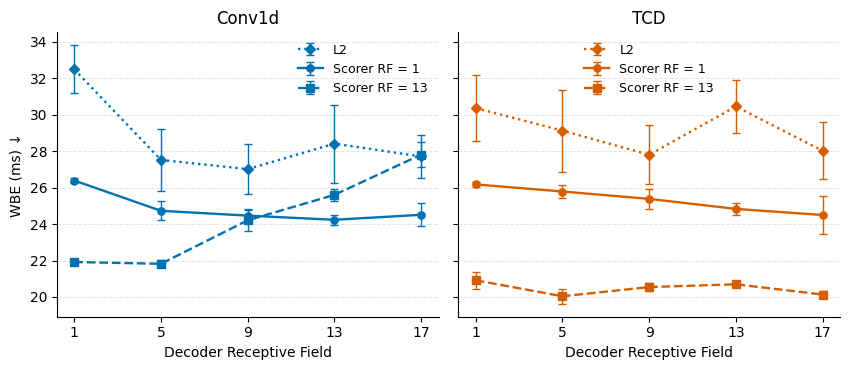

PDF 저장 완료: /shared/data_zfs/blue2959/ND_Aligner/experiments/v2.2/wbe_conv1d_tcd_2panel.pdf
PNG 저장 완료: /shared/data_zfs/blue2959/ND_Aligner/experiments/v2.2/wbe_conv1d_tcd_2panel.png


In [9]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(8.6, 3.8),
    sharex=True,
    sharey=True,
)

# Each decoder architecture uses one consistent color.
# Scorer settings are distinguished by line style and marker.
DECODER_COLORS = {
    "Conv1d": "#0072B2",
    "TCD": "#D55E00",
}

SCORER_STYLES = {
    "l2": {
        "label": "L2",
        "linestyle": ":",
        "marker": "D",
    },
    "1": {
        "label": "Scorer RF = 1",
        "linestyle": "-",
        "marker": "o",
    },
    "13": {
        "label": "Scorer RF = 13",
        "linestyle": "--",
        "marker": "s",
    },
}


def draw_line(
    ax,
    line_df,
    label,
    *,
    linestyle,
    marker,
    color,
):
    ax.errorbar(
        x=line_df["decoder_rf"],
        y=line_df["wbe_mean"],
        yerr=line_df["wbe_std"],
        label=label,
        linestyle=linestyle,
        marker=marker,
        color=color,
        markersize=5.2,
        linewidth=1.7,
        elinewidth=1.0,
        capsize=2.8,
        capthick=1.0,
        zorder=3,
    )


# Problem -> proposed solution ordering
for ax, decoder_type in zip(
    axes,
    ["Conv1d", "TCD"],
):
    decoder_color = DECODER_COLORS[decoder_type]

    for scorer_rf in ["l2", "1", "13"]:
        line_df = (
            summary_df[
                (summary_df["decoder_type"] == decoder_type)
                & (summary_df["scorer_rf"] == scorer_rf)
            ]
            .sort_values("decoder_rf")
        )

        if line_df.empty:
            print(
                f"[경고] {decoder_type}, scorer_rf={scorer_rf} 결과 없음"
            )
            continue

        style = SCORER_STYLES[scorer_rf]

        draw_line(
            ax,
            line_df,
            style["label"],
            linestyle=style["linestyle"],
            marker=style["marker"],
            color=decoder_color,
        )

    ax.set_title(decoder_type)
    ax.set_xlabel("Decoder Receptive Field")
    ax.set_xticks(DECODER_RFS)

    ax.grid(
        axis="y",
        linestyle="--",
        linewidth=0.7,
        alpha=0.35,
        zorder=0,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        frameon=False,
        fontsize=9,
    )

axes[0].set_ylabel("WBE (ms) ↓")

fig.tight_layout()

fig.savefig(
    OUTPUT_PDF,
    bbox_inches="tight",
)

fig.savefig(
    OUTPUT_PNG,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"PDF 저장 완료: {OUTPUT_PDF}")
print(f"PNG 저장 완료: {OUTPUT_PNG}")
